In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings("ignore")  # put near the top
# code that emits warnings to stderr
warnings.filterwarnings("ignore", module="matplotlib")

In [3]:
import nease

In [4]:
import gc

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np

In [7]:
gc.enable()

In [8]:
gc.collect()

69

In [9]:
SE_MATS = pd.read_csv("G2_G0_DOX_concat_38/SE.MATS.JCEC.txt", sep = "\t")

In [10]:
SE_MATS

,ID,GeneID,geneSymbol,chr,strand,exonStart_0base,exonEnd,upstreamES,upstreamEE,downstreamES,...,SJC_SAMPLE_1,IJC_SAMPLE_2,SJC_SAMPLE_2,IncFormLen,SkipFormLen,PValue,FDR,IncLevel1,IncLevel2,IncLevelDifference
0,53,ENSG00000304816,NaN,chrGL000221.1,+,38227,38400,36502,36597,38553,...,"0,0,0","0,0,1","0,0,1",248,75,1.0,1.0,"1.0,1.0,1.0","NA,NA,0.232",0.768
1,75,ENSG00000307088,NaN,chrGL000205.2,-,126684,126764,105829,106033,136473,...,"0,0,1","3,0,1","2,0,0",155,75,1.0,1.0,"1.0,NA,0.0","0.421,NA,1.0",-0.211
2,84,ENSG00000307088,NaN,chrGL000205.2,-,129539,129626,105829,106033,136473,...,"0,0,1","4,1,4","2,0,0",162,75,1.0,1.0,"1.0,NA,0.649","0.481,1.0,1.0",-0.002
3,88,ENSG00000307088,NaN,chrGL000205.2,-,129550,129626,105812,106033,136473,...,"0,0,1","3,1,4","2,0,0",151,75,1.0,1.0,"1.0,NA,0.665","0.427,1.0,1.0",0.023
4,92,ENSG00000307088,NaN,chrGL000205.2,-,129550,129626,126684,126764,136473,...,"2,0,0","3,1,4","3,0,1",151,75,1.0,1.0,"0.332,NA,1.0","0.332,1.0,0.665",0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50866,123333,ENSG00000153922,CHD1,chr5,-,98889075,98889238,98885577,98885649,98892524,...,"0,0,0","115,92,95","1,0,0",238,75,1.0,1.0,"1.0,1.0,1.0","0.973,1.0,1.0",0.009
50867,123334,ENSG00000153922,CHD1,chr5,-,98901185,98901335,98900810,98901082,98902899,...,"0,1,0","158,98,141","0,0,0",225,75,1.0,1.0,"1.0,0.981,1.0","1.0,1.0,1.0",-0.006
50868,123456,ENSG00000113272,THG1L,chr5,+,157738621,157738734,157737909,157737994,157739320,...,"24,31,20","0,0,1","27,15,30",188,75,1.0,1.0,"0.0,0.0,0.0","0.0,0.0,0.013",-0.004
50869,123460,ENSG00000164978,NUDT2,chr9,+,34336228,34336341,34329568,34329599,34338712,...,"1,0,0","1,0,0","4,0,1",188,75,1.0,1.0,"0.666,NA,1.0","0.091,NA,0.0",0.787


In [11]:

SE_MATS_FDR = SE_MATS[(SE_MATS['FDR'] < 0.01) & (SE_MATS['IncLevelDifference'].abs() > 0.25)]


In [12]:
SE_MATS_FDR

,ID,GeneID,geneSymbol,chr,strand,exonStart_0base,exonEnd,upstreamES,upstreamEE,downstreamES,...,SJC_SAMPLE_1,IJC_SAMPLE_2,SJC_SAMPLE_2,IncFormLen,SkipFormLen,PValue,FDR,IncLevel1,IncLevel2,IncLevelDifference
459,1854,ENSG00000186575,NF2,chr22,+,29683019,29683064,29681438,29681601,29694751,...,"12,11,9","16,15,26","25,34,33",120,75,0.000000e+00,0.000000e+00,"0.772,0.787,0.758","0.286,0.216,0.33",0.495
460,1855,ENSG00000186575,NF2,chr22,+,29683019,29683079,29681438,29681601,29694751,...,"12,11,9","12,6,9","25,34,33",135,75,1.391554e-12,3.539486e-09,"0.589,0.537,0.587","0.211,0.089,0.132",0.427
498,1900,ENSG00000100150,DEPDC5,chr22,+,31821501,31821637,31819021,31819225,31833914,...,"6,1,2","13,5,8","1,0,0",211,75,2.592007e-05,4.094969e-03,"0.348,0.81,0.615","0.822,1.0,1.0",-0.350
549,1965,ENSG00000100401,RANGAP1,chr22,-,41284900,41285153,41280932,41281082,41285362,...,"0,0,0","17,20,28","2,1,6",328,75,1.822305e-07,9.459434e-05,"1.0,1.0,1.0","0.66,0.821,0.516",0.334
641,2182,ENSG00000100211,CBY1,chr22,+,38656955,38657143,38656639,38656750,38668016,...,"5,3,5","14,11,11","1,0,1",263,75,1.663502e-05,2.963081e-03,"0.386,0.588,0.222","0.8,1.0,0.758",-0.454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47590,114603,ENSG00000204271,SPIN3,chrX,-,56978291,56978498,56975141,56977196,56978579,...,"1,0,3","4,1,2","1,0,0",282,75,8.016026e-08,4.581835e-05,"0.0,1.0,0.0","0.515,1.0,1.0",-0.505
48468,116861,ENSG00000070501,POLB,chr8,+,42339011,42339069,42338481,42338685,42344952,...,"15,12,12","41,20,37","32,19,37",133,75,2.815814e-06,8.328097e-04,"0.628,0.693,0.647","0.419,0.372,0.361",0.272
49869,120717,ENSG00000188283,ZNF383,chr19,+,37219598,37219749,37217925,37218274,37224817,...,"0,0,0","2,0,3","3,2,1",226,75,1.248663e-09,1.245504e-06,"1.0,1.0,1.0","0.181,0.0,0.499",0.773
50370,121657,ENSG00000290924,NaN,chr9,+,85829462,85829606,85822879,85823080,85837758,...,"0,0,0","13,9,10","4,2,2",219,75,2.403308e-07,1.153384e-04,"1.0,1.0,1.0","0.527,0.606,0.631",0.412


In [13]:
SE_MATS_FDR.to_csv("nease_df_G2_G0_DOX_SE_concact_38_FDR_0.01.csv")

In [14]:
SE_MATS_FDR.dtypes

ID                      int64
GeneID                 object
geneSymbol             object
chr                    object
strand                 object
exonStart_0base         int64
exonEnd                 int64
upstreamES              int64
upstreamEE              int64
downstreamES            int64
downstreamEE            int64
ID.1                    int64
IJC_SAMPLE_1           object
SJC_SAMPLE_1           object
IJC_SAMPLE_2           object
SJC_SAMPLE_2           object
IncFormLen              int64
SkipFormLen             int64
PValue                float64
FDR                   float64
IncLevel1              object
IncLevel2              object
IncLevelDifference    float64
dtype: object

In [15]:
# Run NEASE analysis
events = nease.run(
    SE_MATS_FDR,
    organism='Human',  # or 'Mouse'
    input_type='rmats',
    remove_non_in_frame=True,
    only_divisible_by_3=False
)



You selected to remove all exons that are predicted to disturb the ORF or known to result in a non-coding gene.
If you would like to change this option and include all exons, please change the parameter remove_non_in_frame to False. 

		Data Summary
**************************************************
43 protein domains are affected by AS.

0 linear motifs are affected by AS.
9 interacting residue are affected by AS.

24 of the affected domains/motifs have known interactions.
279 protein interactions/binding affected.

**************************************************
Running enrichment analysis...
NEASE enrichment done.


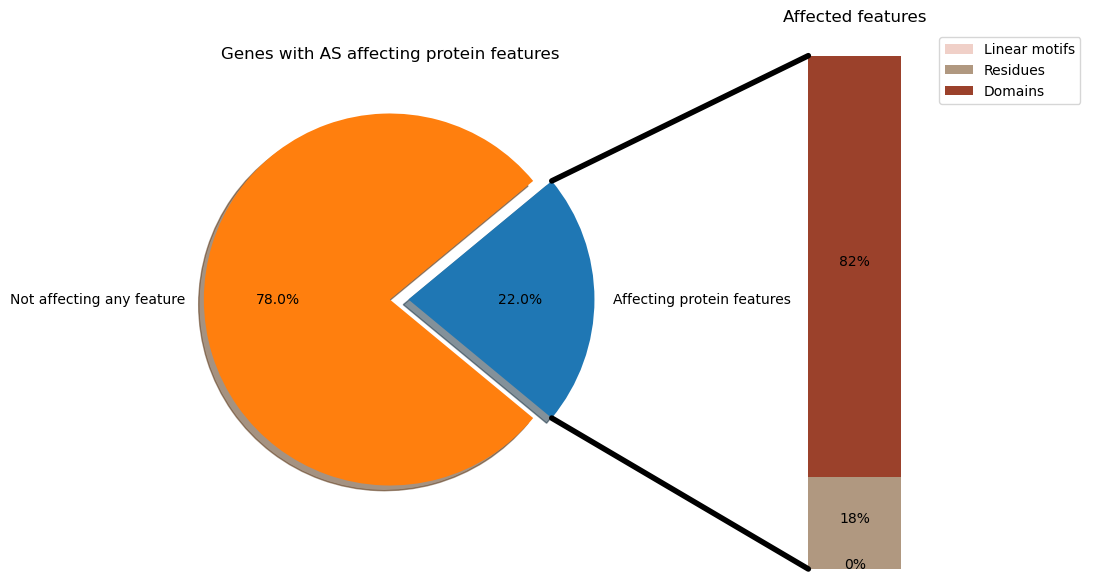

None


In [16]:
# View summary statistics
stats = events.get_stats()
print(stats)


In [17]:
# Get affected domains
# Get list of all protein domais affected by AS.
# A link to DIGGER database for lost/gained domain and their binding.

domains = events.get_domains()
print(domains.head())


  Gene name NCBI gene ID   Gene stable ID   Exon stable ID  Pfam ID   dPSI  \
0   LRRFIP1         9208  ENSG00000124831  ENSE00000850761  PF09738  1.000   
1    RHEBL1       121268  ENSG00000167550  ENSE00002363548  PF00071  0.891   
2     SNX22        79856  ENSG00000157734  ENSE00001034629  PF00787  0.775   
3  GOLGA6L9       440295  ENSG00000197978  ENSE00003737493  PF15070  0.689   
4   EPB41L3        23136  ENSG00000082397  ENSE00003464036  PF00373  0.679   

   Interacting domain Interaction type  \
0               False             None   
1                True              DDI   
2                True              DDI   
3               False             None   
4                True              DDI   

                                              Visualization link  
0                                                                 
1  https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00002363548  
2  https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00001034629  
3         

In [18]:
domains

,Gene name,NCBI gene ID,Gene stable ID,Exon stable ID,Pfam ID,dPSI,Interacting domain,Interaction type,Visualization link
0,LRRFIP1,9208,ENSG00000124831,ENSE00000850761,PF09738,1.000,False,None,
1,RHEBL1,121268,ENSG00000167550,ENSE00002363548,PF00071,0.891,True,DDI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00002363548
2,SNX22,79856,ENSG00000157734,ENSE00001034629,PF00787,0.775,True,DDI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00001034629
3,GOLGA6L9,440295,ENSG00000197978,ENSE00003737493,PF15070,0.689,False,None,
4,EPB41L3,23136,ENSG00000082397,ENSE00003464036,PF00373,0.679,True,DDI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00003464036
5,CHD1L,9557,ENSG00000131778,ENSE00003654599,PF00176,0.594,True,DDI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00003654599
6,PPIA,5478,ENSG00000196262,ENSE00003646478,PF00160,0.510,True,DDI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00003646478
7,CDK20,23552,ENSG00000156345,ENSE00003532544,PF00069,-0.493,True,DDI and DMI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00003532544
8,ITGA6,3655,ENSG00000091409,ENSE00000882762,PF00357,0.483,True,DDI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00000882762
9,PTPN23,25930,ENSG00000076201,ENSE00001054636,PF03097,0.472,True,DDI,https://exbio.wzw.tum.de/digger/ID/exon/human/ENSE00001054636


In [19]:
domains.to_csv("domain_G2_G0_DOX_concat_38_FDR_0.01.csv")

In [20]:

print(events.enrichment)

            Pathway ID  \
0         R-HSA-194840   
1     rac1_reg_pathway   
2        path:hsa04810   
3         R-HSA-194315   
4                 WP51   
...                ...   
4472     path:hsa00250   
4473            WP4129   
4474          PWY-7210   
4475     ARGSPECAT-PWY   
4476       PA165816969   

                                                            Pathway name  \
0                                                       Rho GTPase cycle   
1                                            Regulation of RAC1 activity   
2                Regulation of actin cytoskeleton - Homo sapiens (human)   
3                                               Signaling by Rho GTPases   
4                                       Regulation of Actin Cytoskeleton   
...                                                                  ...   
4472  Alanine, aspartate and glutamate metabolism - Homo sapiens (human)   
4473              Plasma lipoprotein assembly, remodeling, and clearance   
447

In [21]:
events.get_edges()

,Gene name,NCBI gene ID,Identifier,dPSI,Number of affected interactions,Affected binding,Affected binding (NCBI)
0,RAC1,5879,PF00071,0.296,103,"PIK3CA,FMNL1,TIAM1,RAC3,RGL2,CSNK1A1,ARHGEF25,PLEKHA4,ARFIP2,GRB2,PAK6,CTNNB1,ARHGAP15,USH1C,MAP3K4,RAB2A,PARD6A,IQGAP1,KPNA2,SOS1,CIT,ARHGAP32,ARHGAP17,SH3RF2,KPNA6,AKT1,HACE1,DOCK2,ARNT,ARL4A,AGAP1,RAP1GDS1,ARHGDIA,DMPK,PLEKHG2,PHKG2,CDK2,NCF2,PAK1,RAC1,VAV3,ARHGEF4,ARHGAP31,LRRK2,DEF6,DIAPH3,IQGAP2,RALBP1,PARD6G,PAK5,ARHGAP1,IQGAP3,MAP3K11,CDC42SE2,RHOC,USP6,MAP3K10,ARHGAP35,PIK3R1,MYO5B,ARHGAP44,RHOB,PARD6B,VAV1,ARHGDIB,ARHGEF7,CDC42BPG,RCC2,MYO1E,KALRN,KRAS,DOCK1,MCF2L,KPNB1,PAK3,WAS,BCR,PAK2,AGAP2,LATS1,FN1,SH3RF1,TEC,DOCK7,SRC,PTK2,ARHGAP33,ARHGAP27,DOCK8,SH3RF3,ARHGEF6,PAK4,GIT1,RHEB,TRIO,OPHN1,AC004593.2,NOXA1,CDC23,ARHGEF2,SNX31,KPNA4,MAGI1","5290,752,7074,5881,5863,1452,115557,57664,23647,2885,1499,56924,55843,10083,4216,5862,50855,8826,3838,6654,11113,9743,55114,153769,23633,207,57531,1794,405,10124,116987,5910,396,1760,64857,5261,1017,4688,5058,5879,10451,50649,57514,120892,50619,81624,10788,10928,84552,57144,392,128239,4296,56990,389,9098,4294,2909,5295,4645,9912,388,84612,7409,397,8874,55561,55920,4643,8997,3845,1793,23263,3837,5063,7454,613,5062,116986,9113,2335,57630,7006,85440,6714,5747,115703,201176,81704,344558,9459,10298,28964,6009,7204,4983,1124,10811,8697,9181,169166,3840,9223"
1,OGT,8473,PF00515,0.254,29,"KDM6A,CAMK2D,KLF5,WWOX,HIRA,NPHP3,WWP2,SNAI1,RBBP5,YES1,CRKL,DYRK1A,SMURF1,BTRC,PPP1CB,FBXW11,WDR5,HSPA8,BRCA1,CDK2,PPP1CA,HIVEP1,YWHAH,HDAC5,WDR4,ATG16L1,ZBTB38,CSNK2A1,HIVEP2","7403,817,51741,7290,688,27031,11060,6615,5929,7525,1399,1859,57154,8945,5500,23291,11091,3312,672,1017,5499,3096,7533,10014,10785,55054,253461,1457,3097"
2,CDK20,23552,PF00069,-0.493,24,"MAK,FOXJ1,RAF1,SMC1A,LARP7,CSNK2B,RBBP4,PSMD1,CDK5,PPP5C,ATP1A1,ICK,HDAC1,RHOT1,CDK12,CDK2,ZNF146,CCNH,CDC42EP1,EEF2,FKBP8,CDK7,PSMB2,PSMB5","2302,4117,5894,8243,51574,1460,5690,5928,5707,1020,476,5536,22858,3065,55288,51755,1017,902,7705,11135,23770,1022,1938,5693"
3,PPIA,5478,PF00160,0.510,23,"MKNK1,NEDD8,RBM4,PKN3,AKT1,CDK9,RAD23B,SRPK2,G3BP1,FUS,DUSP9,DUSP4,HNRNPA1,PRKCZ,ELAVL1,EWSR1,CDK2,PPP3CA,H2AX,HDAC5,PRPF8,SRPK1,U2AF2","8569,4738,5936,29941,207,1025,5887,6733,10146,2521,1852,1846,3178,5590,1994,2130,1017,5530,3014,10014,10594,6732,11338"
4,CHD1L,9557,PF00176,0.594,18,"SSRP1,H2AC19,H2BC21,H2BC3,TRIM33,EIF4A1,H2AW,CBX3,CIAO1,H2BC12,CBX5,H2BC8,HNRNPL,CBX1,H2AX,H2BC1,HLTF,H2AZ1","3014,6749,8349,723790,3018,3191,51592,1973,11335,9391,85236,23468,6596,10951,92815,255626,8339,3015"
5,MTA1,9112,PF01426,0.252,18,"CHD5,MTA2,DNMT1,H3,MTA3,EP300,CHD4,H3C1,TRIM33,DNMT3B,MACROH2A1,PHF1,H3C14,ZMYND8,H4C1,CHD3,H2AX,H2AZ1","26038,9219,1786,8290,2033,1108,8350,51592,1789,9555,3015,5252,126961,23613,8359,1107,3014,57504"
6,FGFR3,2261,PF07679,0.351,13,"ANOS1,SRPK2,FGFR2,FGF8,FGF9,CDK6,FGFR3,NECTIN1,FGF1,MAP3K4,EPHA4,RPS6KA3,KLB","3730,6733,2263,2253,2254,1021,2261,5818,2246,152831,2043,6197,4216"
7,FGFR3,2261,PF13927,-0.470,9,"ANOS1,FGFR2,FGF8,FGF9,FGF1,FGFR3,NECTIN1,EPHA4,CSPG4","3730,2263,2253,2254,2246,2261,5818,2043,1464"
8,APBB3,10307,PF00640,-0.340,6,"BLK,APLP1,APLP2,DAPP1,APP,EGFR","640,333,334,27071,351,1956"
9,KIF23,9493,PF00225,0.316,6,"DYRK1A,CLK1,LATS2,STK11,PRKCI,MAP3K4","1195,1859,26524,6794,5584,4216"


In [22]:
events.get_edges().to_csv('edge_G2_G0_DOX_concat_38_FDR_0.01.csv')

In [23]:
#Get a list of all affected linear motifs
events.get_elm()

No known linear motif are affected by AS


In [24]:
#events.get_elm().to_csv("elm_G2_G0_DOX_concat_38_FDR_0.01.csv")

In [25]:
# get interacting residues affected by AS
events.get_pdb()

,Gene name,NCBI gene ID,Gene stable ID,Co-resolved interactions symbol,Co-resolved interactions
0,OGT,8473,ENSG00000147162,OGT,8473
1,UAP1,6675,ENSG00000117143,UAP1,6675
2,PPIA,5478,ENSG00000196262,PPP3CA,5530
3,PRELID3A,10650,ENSG00000141391,TRIAP1,51499
4,NF2,4771,ENSG00000186575,NF2,4771
5,INSR,3643,ENSG00000171105,"INS,INS","723961,3630"
6,PTPN23,25930,ENSG00000076201,PTPN23,25930
7,FGFR3,2261,ENSG00000068078,FGF1,2246
8,RAC1,5879,ENSG00000136238,DOCK2,1794


In [26]:
events.get_pdb().to_csv("pdb_G2_G0_DOX_concat_38_FDR_0.01.csv")

In [27]:
pathways = events.enrichment

In [28]:
pathways

,Pathway ID,Pathway name,Source,Spliced genes (number of interactions affecting the pathway),p_value,Nease score
0,R-HSA-194840,Rho GTPase cycle,Reactome,"CDK20 (1), RAC1 (31)",8.278337e-20,19.082057
1,rac1_reg_pathway,Regulation of RAC1 activity,PID,RAC1 (21),6.831255e-17,16.165500
2,path:hsa04810,Regulation of actin cytoskeleton - Homo sapiens (human),KEGG,"EPB41L3 (2), CDK20 (1), ITGA6 (1), FGFR3 (5), APBB3 (1), RAC1 (29), OGT (3), INSR (1)",2.058049e-12,23.373088
3,R-HSA-194315,Signaling by Rho GTPases,Reactome,"CHD1L (8), PPIA (2), CDK20 (1), ITGA6 (1), TAP2 (1), RAC1 (48), OGT (2), MTA1 (5), NF2 (1)",7.399809e-11,17.547025
4,WP51,Regulation of Actin Cytoskeleton,Wikipathways,"EPB41L3 (2), CDK20 (1), FGFR3 (5), APBB3 (1), RAC1 (24)",2.532968e-09,14.889350
...,...,...,...,...,...,...
4472,path:hsa00250,"Alanine, aspartate and glutamate metabolism - Homo sapiens (human)",KEGG,,1.000000e+00,0.000000
4473,WP4129,"Plasma lipoprotein assembly, remodeling, and clearance",Wikipathways,,1.000000e+00,0.000000
4474,PWY-7210,pyrimidine deoxyribonucleotides biosynthesis from CTP,HumanCyc,,1.000000e+00,0.000000
4475,ARGSPECAT-PWY,spermine biosynthesis,HumanCyc,,1.000000e+00,0.000000


In [29]:
pathways_sorted = pathways.sort_values(by='Nease score', ascending=False)

In [30]:
pathways_sorted

,Pathway ID,Pathway name,Source,Spliced genes (number of interactions affecting the pathway),p_value,Nease score
2,path:hsa04810,Regulation of actin cytoskeleton - Homo sapiens (human),KEGG,"EPB41L3 (2), CDK20 (1), ITGA6 (1), FGFR3 (5), APBB3 (1), RAC1 (29), OGT (3), INSR (1)",2.058049e-12,23.373088
0,R-HSA-194840,Rho GTPase cycle,Reactome,"CDK20 (1), RAC1 (31)",8.278337e-20,19.082057
3,R-HSA-194315,Signaling by Rho GTPases,Reactome,"CHD1L (8), PPIA (2), CDK20 (1), ITGA6 (1), TAP2 (1), RAC1 (48), OGT (2), MTA1 (5), NF2 (1)",7.399809e-11,17.547025
1,rac1_reg_pathway,Regulation of RAC1 activity,PID,RAC1 (21),6.831255e-17,16.165500
4,WP51,Regulation of Actin Cytoskeleton,Wikipathways,"EPB41L3 (2), CDK20 (1), FGFR3 (5), APBB3 (1), RAC1 (24)",2.532968e-09,14.889350
...,...,...,...,...,...,...
1696,WP2814,Mammary gland development pathway - Puberty (Stage 2 of 4),Wikipathways,RAC1 (1),8.143219e-01,0.000000
1695,p53downstreampathway,Direct p53 effectors,PID,"TAP2 (1), PRELID3A (1), APBB3 (1), RAC1 (1), MTA1 (1)",8.141869e-01,0.000000
1694,path:hsa04925,Aldosterone synthesis and secretion - Homo sapiens (human),KEGG,"CDK20 (1), OGT (1)",8.105085e-01,0.000000
1693,WP2361,Gastric Cancer Network 1,Wikipathways,JAG2 (1),8.094962e-01,0.000000


In [31]:
# Run nease enrichment on affected edges
nease_enr_KEGG=events.enrich(database=['KEGG'])
nease_enr_KEGG.head(10)

NEASE enrichment for the pathway databases:
 ['KEGG']
Found 6 enriched pathways after multiple testing correction.



,Pathway ID,Pathway name,Source,Spliced genes (number of interactions affecting the pathway),p_value,adj p_value,Nease score
0,path:hsa04810,Regulation of actin cytoskeleton - Homo sapiens (human),KEGG,"EPB41L3 (2), CDK20 (1), ITGA6 (1), FGFR3 (5), APBB3 (1), RAC1 (29), OGT (3), INSR (1)",2.058049e-12,6.585758e-10,23.373088
1,path:hsa04015,Rap1 signaling pathway - Homo sapiens (human),KEGG,"EPB41L3 (2), PPIA (2), CDK20 (1), ITGA6 (1), FGFR3 (5), APBB3 (1), KIF23 (1), RAC1 (13), OGT (1), INSR (1)",3.500855e-04,2.800684e-02,6.911652
2,path:hsa04360,Axon guidance - Homo sapiens (human),KEGG,"EPB41L3 (2), PPIA (2), CDK20 (2), ITGA6 (1), FGFR3 (1), RAC1 (16), OGT (1)",1.127510e-04,1.561254e-02,6.837928
3,path:hsa05165,Human papillomavirus infection - Homo sapiens (human),KEGG,"RHEBL1 (1), SNX22 (1), EPB41L3 (2), PPIA (4), CDK20 (3), ITGA6 (1), FGFR3 (1), APBB3 (1), KIF23 (1), JAG2 (3), RAC1 (16), OGT (2), MTA1 (2)",1.463676e-04,1.561254e-02,6.641644
4,path:hsa05211,Renal cell carcinoma - Homo sapiens (human),KEGG,"EPB41L3 (2), PPIA (1), CDK20 (1), RAC1 (14), OGT (1), MTA1 (1)",6.611753e-04,3.526268e-02,4.496751
5,path:hsa04014,Ras signaling pathway - Homo sapiens (human),KEGG,"EPB41L3 (2), PPIA (1), CDK20 (1), FGFR3 (5), APBB3 (1), RAC1 (17), INSR (1)",2.626301e-03,1.200595e-01,4.469826
6,path:hsa05226,Gastric cancer - Homo sapiens (human),KEGG,"RHEBL1 (1), SNX22 (1), EPB41L3 (2), PPIA (2), CDK20 (2), FGFR3 (4), APBB3 (1), RAC1 (9), OGT (1)",3.651028e-03,1.460411e-01,4.222021
7,path:hsa05224,Breast cancer - Homo sapiens (human),KEGG,"RHEBL1 (1), SNX22 (1), EPB41L3 (2), PPIA (1), CDK20 (1), FGFR3 (4), APBB3 (1), JAG2 (3), RAC1 (8), OGT (1)",1.044410e-02,2.909521e-01,3.431416
8,path:hsa04010,MAPK signaling pathway - Homo sapiens (human),KEGG,"EPB41L3 (2), PPIA (5), CDK20 (2), FGFR3 (7), APBB3 (1), KIF23 (1), RAC1 (10), OGT (2), INSR (1)",1.115033e-02,2.909521e-01,3.382197
9,path:hsa04510,Focal adhesion - Homo sapiens (human),KEGG,"PPIA (1), CDK20 (1), ITGA6 (1), APBB3 (1), RAC1 (21), OGT (3)",6.583642e-04,3.526268e-02,3.181534


In [32]:
nease_enr_KEGG.to_csv("SE_nease_enrichment_edge_KEGG_G2_G0_DOX_FDR_0.01.csv")

In [33]:
# Run nease enrichment on affected edges
nease_enr_Reactome=events.enrich(database=['Reactome'])
nease_enr_Reactome.head(20)

NEASE enrichment for the pathway databases:
 ['Reactome']
Found 44 enriched pathways after multiple testing correction.



,Pathway ID,Pathway name,Source,Spliced genes (number of interactions affecting the pathway),p_value,adj p_value,Nease score
0,R-HSA-194840,Rho GTPase cycle,Reactome,"CDK20 (1), RAC1 (31)",8.278337e-20,1.452020e-16,19.082057
1,R-HSA-194315,Signaling by Rho GTPases,Reactome,"CHD1L (8), PPIA (2), CDK20 (1), ITGA6 (1), TAP2 (1), RAC1 (48), OGT (2), MTA1 (5), NF2 (1)",7.399809e-11,6.489632e-08,17.547025
2,R-HSA-162582,Signal Transduction,Reactome,"RHEBL1 (1), SNX22 (2), EPB41L3 (3), CHD1L (9), PPIA (13), CDK20 (9), ITGA6 (1), FGFR3 (8), MYSM1 (1), TAP2 (1), APBB3 (2), KIF23 (3), JAG2 (3), RAC1 (63), OGT (15), MTA1 (12), NF2 (1), INSR (1)",2.643764e-09,1.545721e-06,14.857146
3,R-HSA-193648,NRAGE signals death through JNK,Reactome,RAC1 (13),1.023008e-07,4.485890e-05,6.990121
4,R-HSA-416482,G alpha (12/13) signalling events,Reactome,RAC1 (17),3.167376e-07,1.111116e-04,6.499300
5,R-HSA-74751,Insulin receptor signalling cascade,Reactome,"EPB41L3 (2), FGFR3 (6), RAC1 (5), INSR (1)",9.463067e-04,4.255954e-02,6.047936
6,R-HSA-112399,IRS-mediated signalling,Reactome,"EPB41L3 (2), FGFR3 (6), RAC1 (5)",3.466475e-04,2.911423e-02,5.993090
7,R-HSA-5655332,Signaling by FGFR3 in disease,Reactome,"EPB41L3 (2), FGFR3 (4), RAC1 (5)",3.608969e-04,2.911423e-02,5.962787
8,R-HSA-8853338,Signaling by FGFR3 point mutants in cancer,Reactome,"EPB41L3 (2), FGFR3 (4), RAC1 (5)",3.608969e-04,2.911423e-02,5.962787
9,R-HSA-5655253,Signaling by FGFR2 in disease,Reactome,"EPB41L3 (2), FGFR3 (4), RAC1 (5)",4.409672e-04,3.362854e-02,5.812059


In [34]:
nease_enr_Reactome.to_csv("SE_nease_enrichment_edge_Reactome_G2_G0_DOX_FDR_0.01.csv")

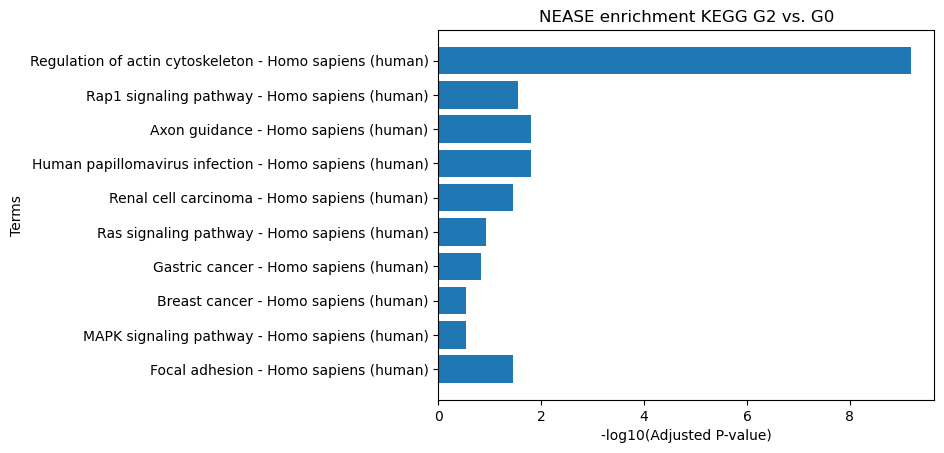

In [35]:
#plot nease enrichment for KEGG
nease_enr_KEGG=nease_enr_KEGG.sort_values(by='Nease score',ascending=False)
Term = nease_enr_KEGG['Pathway name'][:10]
Pvalues =nease_enr_KEGG['adj p_value'][:10]
Pvalues=[ -np.log10(x) for x in Pvalues]

plt.barh(Term[::-1],Pvalues[::-1] )
plt.title('NEASE enrichment KEGG G2 vs. G0')
plt.ylabel('Terms')
plt.xlabel('-log10(Adjusted P-value)')
plt.savefig('NEASE_enrichment_KEGG_G2_G0.pdf',format='pdf',bbox_inches='tight')
plt.show()

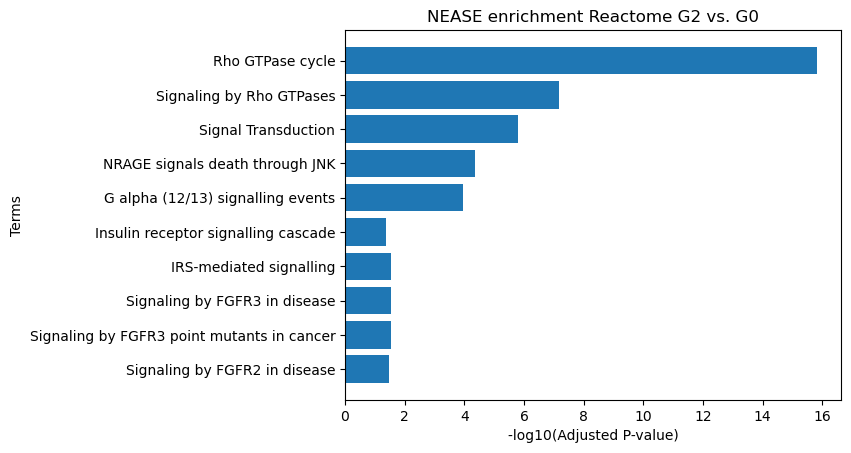

In [36]:
#plot nease enrichment for Reactome
nease_enr_Reactome=nease_enr_Reactome.sort_values(by='Nease score',ascending=False)
Term = nease_enr_Reactome['Pathway name'][:10]
Pvalues =nease_enr_Reactome['adj p_value'][:10]
Pvalues=[ -np.log10(x) for x in Pvalues]

plt.barh(Term[::-1],Pvalues[::-1] )
plt.title('NEASE enrichment Reactome G2 vs. G0')
plt.ylabel('Terms')
plt.xlabel('-log10(Adjusted P-value)')
plt.savefig('NEASE_enrichment_Reactome_G2_G0.pdf',format='pdf',bbox_inches='tight')
plt.show()

In [37]:
SE_best_path_KEGG = events.path_analysis('path:hsa04810')
SE_best_path_KEGG

Enrichment of the pathway: Regulation of actin cytoskeleton - Homo sapiens (human).

Overall p_value:  2.0580494696874897e-12




,Spliced genes,NCBI gene ID,Gene is known to be in the pathway,Percentage of edges associated to the pathway,p_value,Affected binding (edges),Affected binding (NCBI)
0,RAC1,5879,True,29/103,9.795769e-16,"PIK3CA,TIAM1,RAC3,PAK6,IQGAP1,SOS1,PAK1,RAC1,VAV3,ARHGEF4,DIAPH3,IQGAP2,PAK5,IQGAP3,ARHGAP35,PIK3R1,VAV1,ARHGEF7,KRAS,DOCK1,PAK3,WAS,PAK2,FN1,SRC,PTK2,ARHGEF6,PAK4,GIT1","5290,7074,5881,56924,8826,6654,5058,5879,10451,50649,81624,10788,57144,128239,2909,5295,7409,8874,3845,1793,5063,7454,5062,2335,6714,5747,9459,10298,28964"
1,FGFR3,2261,True,5/14,2.585409e-04,"FGFR2,FGF8,FGF9,FGF1,FGFR3","2263,2253,2254,2246,2261"
2,EPB41L3,23136,False,2/5,1.838715e-02,"KRAS,NRAS","3845,4893"
3,ITGA6,3655,True,1/1,4.487424e-02,ITGB1,3688
4,INSR,3643,False,1/2,8.773514e-02,INS,3630
5,OGT,8473,False,3/30,1.500064e-01,"CRKL,PPP1CB,PPP1CA","1399,5500,5499"
6,APBB3,10307,False,1/6,2.407920e-01,EGFR,1956
7,CDK20,23552,False,1/24,6.677947e-01,RAF1,5894


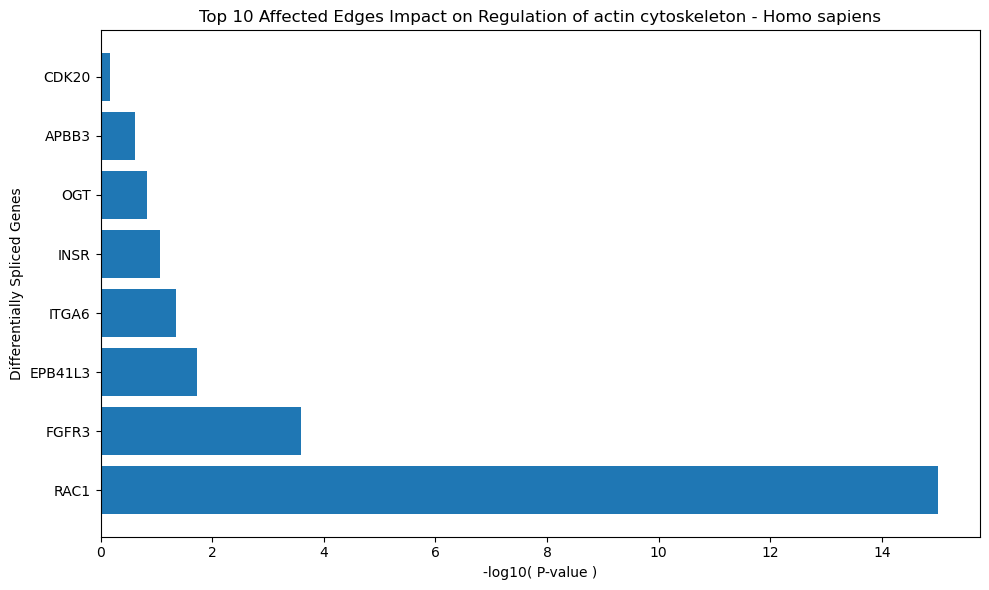

In [38]:
# Extract genes and p-values
Genes = SE_best_path_KEGG['Spliced genes']
Pvalues = SE_best_path_KEGG['p_value']

# Convert p-values to -log10 scale
log_pvalues = [-np.log10(p) for p in Pvalues]

Genes = SE_best_path_KEGG['Spliced genes']
Pvalues = SE_best_path_KEGG['p_value']
Pvalues=[ -np.log10(x) for x in Pvalues]

# Combine and sort by significance
sorted_data = sorted(zip(Genes, log_pvalues), key=lambda x: x[1], reverse=True)

# Select top N most significant genes
N = 10
top_genes, top_log_pvalues = zip(*sorted_data[:N])


# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_genes, top_log_pvalues)
plt.title('Top 10 Affected Edges Impact on Regulation of actin cytoskeleton - Homo sapiens')
plt.xlabel('-log10( P-value )')
plt.ylabel('Differentially Spliced Genes')
plt.tight_layout()
plt.savefig('Top_10_SE_nease_G2_G0_DOX_KEGG_Regulation_of_actin_cytoskeleton.pdf', format='pdf')
plt.show()

In [39]:
#Genes = SE_best_path['Spliced genes']
#Pvalues = SE_best_path['p_value']
#Pvalues=[ -np.log10(x) for x in Pvalues]


#plt.barh(Genes[::-3],Pvalues[::-3])
#plt.title('Affected edges impact on Vesicle-mediated transport')
#plt.ylabel('Differentially spliced genes')
#plt.xlabel('-log10( P-value)')
#plt.savefig('SE_nease_G1_G0_DOX_Vesicle-mediated_transport.pdf',format='pdf',bbox_inches='tight')
#plt.show()

In [40]:
SE_best_path_reactome = events.path_analysis('R-HSA-194840')
SE_best_path_reactome

Enrichment of the pathway: Rho GTPase cycle.

Overall p_value:  8.278337382756578e-20




,Spliced genes,NCBI gene ID,Gene is known to be in the pathway,Percentage of edges associated to the pathway,p_value,Affected binding (edges),Affected binding (NCBI)
0,RAC1,5879,True,31/103,1.109207e-32,"TIAM1,RAC3,ARHGAP15,SOS1,ARHGAP32,ARHGAP17,ARHGDIA,PLEKHG2,RAC1,VAV3,ARHGEF4,ARHGAP31,RALBP1,ARHGAP1,RHOC,ARHGAP35,ARHGAP44,RHOB,VAV1,ARHGDIB,ARHGEF7,KALRN,MCF2L,BCR,ARHGAP33,ARHGAP27,ARHGEF6,TRIO,OPHN1,AC004593.2,ARHGEF2","7074,5881,55843,6654,9743,55114,396,64857,5879,10451,50649,57514,10928,392,389,2909,9912,388,7409,397,8874,8997,23263,613,115703,201176,9459,7204,4983,1124,9181"
1,CDK20,23552,False,1/24,2.826764e-01,RHOT1,55288


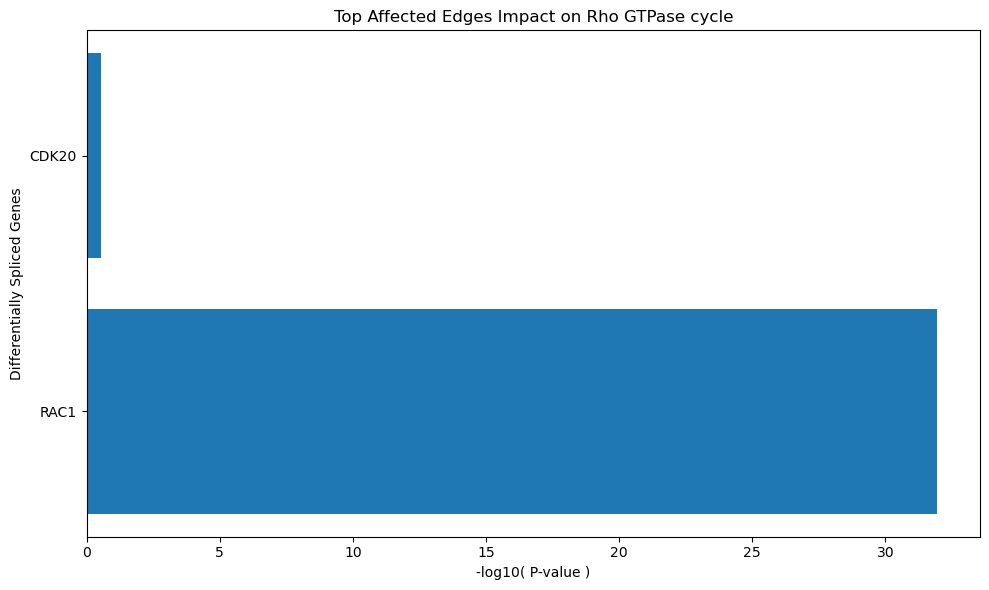

In [41]:
# Extract genes and p-values
Genes = SE_best_path_reactome['Spliced genes']
Pvalues = SE_best_path_reactome['p_value']

# Convert p-values to -log10 scale
log_pvalues = [-np.log10(p) for p in Pvalues]

Genes = SE_best_path_reactome['Spliced genes']
Pvalues = SE_best_path_reactome['p_value']
Pvalues=[ -np.log10(x) for x in Pvalues]

# Combine and sort by significance
sorted_data = sorted(zip(Genes, log_pvalues), key=lambda x: x[1], reverse=True)

# Select top N most significant genes
N = 10
top_genes, top_log_pvalues = zip(*sorted_data[:N])


# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_genes, top_log_pvalues)
plt.title('Top Affected Edges Impact on Rho GTPase cycle')
plt.xlabel('-log10( P-value )')
plt.ylabel('Differentially Spliced Genes')
plt.tight_layout()
plt.savefig('Top_10_SE_nease_G2_G0_DOX_reactome_Rho_GTPase_cycle.pdf', format='pdf')
plt.show()